<a href="https://colab.research.google.com/github/Rayers-Ranjitkar/Rayers_AI_Worksheets/blob/main/Worksheet10_NaiveBayes_Rayers_Ranjitkar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **2. Part 1**

In [54]:
#Importing the essential libraries

import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


In [55]:
# loading dataset
df_imdb = pd.read_csv("/content/drive/MyDrive/Datasets/IMDB Dataset.csv")

# checking dataset
df_imdb.head()



,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**2. Processing Reviews**

In [56]:
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


# setting stopwords and stemmer
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()


# cleaning reviews using worksheet requirements
def clean_review(text):
    # 1 a. converting to lowercase
    text = text.lower()

    # 1 b. removing punctuation and non alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # 1 c. tokenizing and removing stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]

    # 1 d. applying stemming
    words = [stemmer.stem(w) for w in words]

    # joining back into single sentence
    return " ".join(words)



# applying preprocessing on reviews
df_imdb["clean_review"] = df_imdb["review"].apply(clean_review)

# checking cleaned output
df_imdb[["review", "clean_review"]].head()

# converting sentiment into numeric labels
df_imdb["label"] = df_imdb["sentiment"].map({"negative": 0, "positive": 1})

# checking labels
df_imdb[["sentiment", "label"]].head()



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


<br>

In [57]:
# 2. Spliting the dataset into training and testing sets (80% training, 20% testing)

X = df_imdb["clean_review"]
y = df_imdb["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# checking split size
X_train.shape, X_test.shape


((40000,), (10000,))

<br>

In [58]:
# 3. Using a Naive Bayes classifier to classify positive and negative reviews

# 3 a. implementing Bag-of-Words model using CountVectorizer
vectorizer = CountVectorizer(max_features=5000)

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

# checking feature size
X_train_bow.shape


# 3 b. training naive bayes classifier using training set
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)


# predicting on test data
y_pred = nb_model.predict(X_test_bow)

# checking sample predictions
y_pred[:10]


array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0])

# **Part 2 - Evaluating the performance of the model**

In [59]:
# 1 a. Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# 1 b. Precision, Recall, and F1-score
print(classification_report(y_test, y_pred))


# 1 c. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.8427
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      5000
           1       0.85      0.84      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000

[[4234  766]
 [ 807 4193]]


<br>

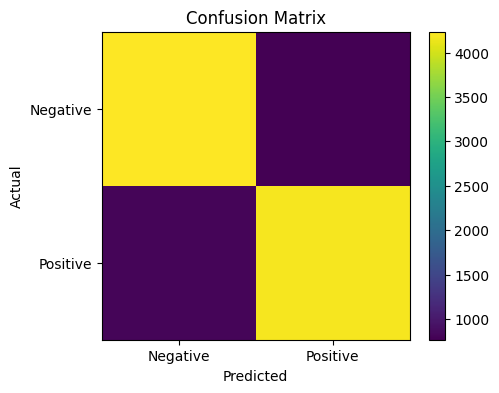

In [60]:
# plotting confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])
plt.colorbar()
plt.grid(False)
plt.show()

<br>

ROC-AUC Score: 0.9107094800000001


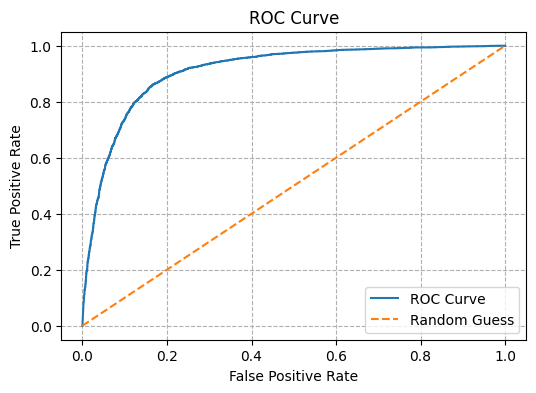

In [61]:
# 1 d. ROC-AUC Score

# getting probability values for positive class
y_prob = nb_model.predict_proba(X_test_bow)[:, 1]

# calculating roc auc
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)


# plotting roc curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--")
plt.show()


<br>

<br>

<br>

# **3.1 Feature Selection using Wrapper Methods.**

In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

Part 1: Data Loading and Preprocessing

In [63]:
df_cancer = pd.read_csv("/content/drive/MyDrive/Datasets/Breast_Cancer.csv")

# checking dataset
print("loaded shape:", df_cancer.shape)
df_cancer.head()

loaded shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [64]:
# 3. basic cleaning + splitting

# dropping extra column if it exists
if "Unnamed: 32" in df_cancer.columns:
    df_cancer = df_cancer.drop(columns=["Unnamed: 32"])

# dropping missing values
df_cancer = df_cancer.dropna()

# separating X and y
y = df_cancer["diagnosis"].map({"M": 1, "B": 0})
X = df_cancer.drop(columns=["diagnosis"])

# dropping id if present
if "id" in X.columns:
    X = X.drop(columns=["id"])

# splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Part 2: Applying Wrapper Method (RFE)

Top 5 selected features:
['radius_se', 'radius_worst', 'texture_worst', 'area_worst', 'concave points_worst']


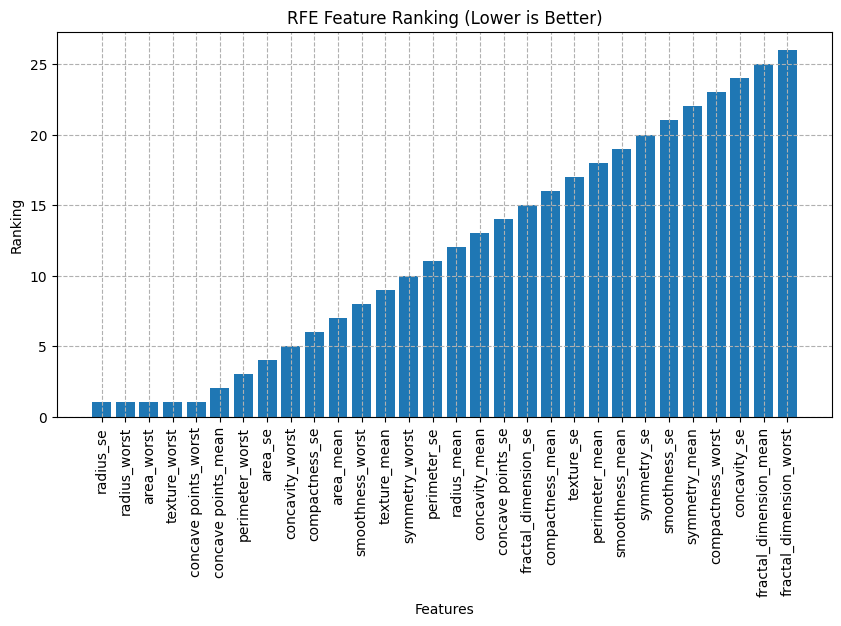

In [65]:
# 1. using rfe with logistic regression to select top 5 features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_base = LogisticRegression(max_iter=2000)

rfe = RFE(estimator=lr_base, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

# selecting top 5 features
top5_features = X.columns[rfe.support_]
print("Top 5 selected features:")
print(list(top5_features))

# visualizing ranking of features
ranking_df = pd.DataFrame({
    "feature": X.columns,
    "ranking": rfe.ranking_
}).sort_values("ranking")

plt.figure(figsize=(10, 5))
plt.bar(ranking_df["feature"], ranking_df["ranking"])
plt.title("RFE Feature Ranking (Lower is Better)")
plt.xlabel("Features")
plt.ylabel("Ranking")
plt.xticks(rotation=90)
plt.grid(True, linestyle="--")
plt.show()


In [66]:
# 2. training logistic regression using only selected features
X_train_top5 = X_train_scaled[:, rfe.support_]
X_test_top5 = X_test_scaled[:, rfe.support_]

lr_top5 = LogisticRegression(max_iter=2000)
lr_top5.fit(X_train_top5, y_train)

LogisticRegression(max_iter=2000)

**Part 3: Model Evaluation**

Top 5 Features Model
Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1-Score: 0.9512195121951219
ROC-AUC: 0.9970238095238095


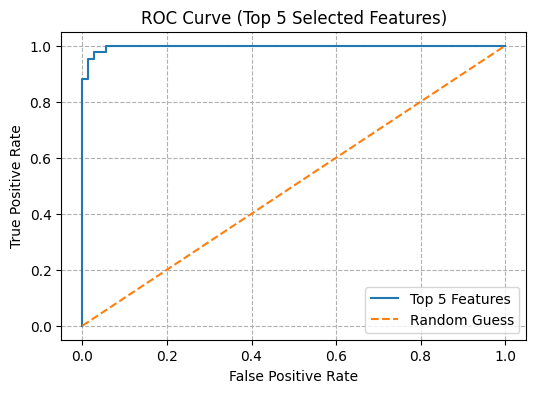

In [67]:
# Part 3: Model Evaluation

# 1. evaluating model trained on selected features
y_pred_top5 = lr_top5.predict(X_test_top5)
y_prob_top5 = lr_top5.predict_proba(X_test_top5)[:, 1]

acc_top5 = accuracy_score(y_test, y_pred_top5)
prec_top5 = precision_score(y_test, y_pred_top5, zero_division=0)
rec_top5 = recall_score(y_test, y_pred_top5, zero_division=0)
f1_top5 = f1_score(y_test, y_pred_top5, zero_division=0)
roc_top5 = roc_auc_score(y_test, y_prob_top5)

print("Top 5 Features Model")
print("Accuracy:", acc_top5)
print("Precision:", prec_top5)
print("Recall:", rec_top5)
print("F1-Score:", f1_top5)
print("ROC-AUC:", roc_top5)

# plotting roc curve for top 5 model
fpr5, tpr5, _ = roc_curve(y_test, y_prob_top5)

plt.figure(figsize=(6, 4))
plt.plot(fpr5, tpr5, label="Top 5 Features")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.title("ROC Curve (Top 5 Selected Features)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--")
plt.show()

In [68]:
# 2. training + evaluating model trained on all features
lr_all = LogisticRegression(max_iter=2000)
lr_all.fit(X_train_scaled, y_train)

y_pred_all = lr_all.predict(X_test_scaled)
y_prob_all = lr_all.predict_proba(X_test_scaled)[:, 1]

acc_all = accuracy_score(y_test, y_pred_all)
prec_all = precision_score(y_test, y_pred_all, zero_division=0)
rec_all = recall_score(y_test, y_pred_all, zero_division=0)
f1_all = f1_score(y_test, y_pred_all, zero_division=0)
roc_all = roc_auc_score(y_test, y_prob_all)

print("\nAll Features Model")
print("Accuracy:", acc_all)
print("Precision:", prec_all)
print("Recall:", rec_all)
print("F1-Score:", f1_all)
print("ROC-AUC:", roc_all)

# comparing in a table
compare_df = pd.DataFrame({
    "model": ["All Features", "Top 5 Selected"],
    "accuracy": [acc_all, acc_top5],
    "precision": [prec_all, prec_top5],
    "recall": [rec_all, rec_top5],
    "f1_score": [f1_all, f1_top5],
    "roc_auc": [roc_all, roc_top5]
})

compare_df


All Features Model
Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1-Score: 0.9512195121951219
ROC-AUC: 0.996031746031746


,model,accuracy,precision,recall,f1_score,roc_auc
0,All Features,0.964912,0.975,0.928571,0.95122,0.996032
1,Top 5 Selected,0.964912,0.975,0.928571,0.95122,0.997024


**Part 4: Experimentation**

In [69]:
# Part 4: Experimenting with different number of features

def train_eval_k(k):
    # selecting k features using rfe
    rfe_k = RFE(estimator=LogisticRegression(max_iter=2000), n_features_to_select=k)
    rfe_k.fit(X_train_scaled, y_train)

    X_train_k = X_train_scaled[:, rfe_k.support_]
    X_test_k = X_test_scaled[:, rfe_k.support_]

    model_k = LogisticRegression(max_iter=2000)
    model_k.fit(X_train_k, y_train)

    pred_k = model_k.predict(X_test_k)
    prob_k = model_k.predict_proba(X_test_k)[:, 1]

    return {
        "k": k,
        "accuracy": accuracy_score(y_test, pred_k),
        "precision": precision_score(y_test, pred_k, zero_division=0),
        "recall": recall_score(y_test, pred_k, zero_division=0),
        "f1_score": f1_score(y_test, pred_k, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob_k)
    }

# experimenting with top 3 and top 7
res3 = train_eval_k(3)
res7 = train_eval_k(7)

exp_df = pd.DataFrame([res3, res7])
exp_df


,k,accuracy,precision,recall,f1_score,roc_auc
0,3,0.947368,0.973684,0.880952,0.925000,0.996362
1,7,0.973684,0.975610,0.952381,0.963855,0.997024


**Discussion:**

- Selecting fewer features (like top 3) makes the model simpler and faster, but it can miss some important info  

- Selecting more features (like top 7) can improve performance, but it may include extra features that don’t really help  

- Feature selection can reduce overfitting and also makes the model easier to understand